# Week 3: Evaluation using reference ground-truth, mitigation, and calibration

You now receive:

- `week3_validation_reference.csv`
- `week3_test_observed.csv`
- `week3_test_reference.csv`

These files let you compare evaluation against the labels available to the modelling pipeline, $Y^{obs}$, and the best available reference labels, $Y^{ref}$.

You now receive the "clean" reference labels (`income_reference`) for the validation and test sets. 

Your objective this week is to uncover the **root cause** of the biases and anomalies you hypothesized in Week 2. By comparing your model's performance against the observed labels ($Y^{obs}$) versus the clean reference labels ($Y^{ref}$), you will finally validate (or invalidate!) your previous hypotheses.

Once you have identified the true source of the bias, you will design and implement a mitigation strategy of your choice to correct it. 

**Rules**
- Do not train a predictive model on `income_reference`.                                    
- Reference validation may be used for final model selection or calibration only if you explicitly state and defend that design choice.                         
- Reference test is used exactly *once* for your final evaluation.                                         
- Preserve `row_id` when joining files and verify one-to-one joins.

In [1]:
%pip -q install fairlearn cleanlab scikit-learn pandas matplotlib seaborn

/home/botmain/Desktop/projects/optim/.venv/bin/python: No module named pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
%matplotlib inline

In [3]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, roc_auc_score,
    log_loss, brier_score_loss, confusion_matrix, precision_score, recall_score,
)
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.frozen import FrozenEstimator

from fairlearn.metrics import MetricFrame, selection_rate
from fairlearn.postprocessing import ThresholdOptimizer
from fairlearn.reductions import EqualizedOdds, ExponentiatedGradient

warnings.filterwarnings("ignore", category=FutureWarning)
RANDOM_STATE = 42
DATA_DIR = Path("./data")

train = pd.read_csv(DATA_DIR / "week2_train_observed.csv")
val_obs = pd.read_csv(DATA_DIR / "week2_validation_observed.csv")
val_ref = pd.read_csv(DATA_DIR / "week3_validation_reference.csv")
test_obs = pd.read_csv(DATA_DIR / "week3_test_observed.csv")
test_ref = pd.read_csv(DATA_DIR / "week3_test_reference.csv")

# --- Integrity: unique row_ids and exact one-to-one alignment -----------------
for name, df in [("train", train), ("val_obs", val_obs), ("val_ref", val_ref),
                 ("test_obs", test_obs), ("test_ref", test_ref)]:
    assert df["row_id"].is_unique, f"{name}: row_id is not unique"

val = val_obs.merge(val_ref[["row_id", "income_reference"]], on="row_id",
                    how="inner", validate="one_to_one")
test = test_obs.merge(test_ref[["row_id", "income_reference"]], on="row_id",
                      how="inner", validate="one_to_one")
assert len(val) == len(val_obs) == len(val_ref), "validation files are misaligned"
assert len(test) == len(test_obs) == len(test_ref), "test files are misaligned"

# --- Feature definition -------------------------------------------------------
# The ten ACS covariates are retained. SEX_group / RACE_group are derived labels
# used only for auditing. SURVEY_BATCH is deliberately excluded: it encodes the
# collection process, would leak the corruption mechanism, and is not a feature
# we could rely on at deployment.
FEATURES = ["AGEP", "COW", "SCHL", "MAR", "OCCP", "POBP", "RELP", "WKHP", "SEX", "RAC1P"]
NUMERIC = ["AGEP", "WKHP"]
CATEGORICAL = [c for c in FEATURES if c not in NUMERIC]
SEX_COL, RACE_COL = "SEX_group", "RACE_group"

assert set(FEATURES).issubset(train.columns)
assert list(train[FEATURES].columns) == list(val[FEATURES].columns) == list(test[FEATURES].columns)

y_obs_train = train["income_observed"].astype(int).values
y_obs_val = val["income_observed"].astype(int).values
y_ref_val = val["income_reference"].astype(int).values
y_obs_test = test["income_observed"].astype(int).values
y_ref_test = test["income_reference"].astype(int).values
A_train, A_val, A_test = train[SEX_COL].values, val[SEX_COL].values, test[SEX_COL].values

print("Split shapes (train, val, test):", train.shape, val.shape, test.shape)
print(f"Predictors: {len(FEATURES)} ({len(NUMERIC)} numeric, {len(CATEGORICAL)} categorical)")
print(f"Positive rate  Y_obs / Y_ref  (train): {y_obs_train.mean():.3f} / -")
print(f"Positive rate  Y_obs / Y_ref  (val)  : {y_obs_val.mean():.3f} / {y_ref_val.mean():.3f}")
print(f"Positive rate  Y_obs / Y_ref  (test) : {y_obs_test.mean():.3f} / {y_ref_test.mean():.3f}")

Split shapes (train, val, test): (18000, 15) (6000, 16) (6000, 16)
Predictors: 10 (2 numeric, 8 categorical)
Positive rate  Y_obs / Y_ref  (train): 0.331 / -
Positive rate  Y_obs / Y_ref  (val)  : 0.334 / 0.365
Positive rate  Y_obs / Y_ref  (test) : 0.332 / 0.365


To start with - Compare $Y^{obs}$ and $Y^{ref}$ on validation and test data. Report overall disagreement, disagreement conditional on each label, group-specific disagreement, and intersections. Inspect which feature regions contain disagreements without assuming the reference label is infallible.

Overall disagreement  validation: 4.0333%
Overall disagreement  test:        4.1500%

Validation contingency table:


Y_obs,0,1,All
Y_ref,,,
0,3782,30,3812
1,212,1976,2188
All,3994,2006,6000


P(Y_obs=0 | Y_ref=1)  high earners recorded as low: 3.5333%
P(Y_obs=1 | Y_ref=0)  spurious positives:           0.5000%

Disagreement by sex:


,count,disagreement
SEX_group,,
Female,2812,0.0725
Male,3188,0.0119


Disagreement by race:


...

,count,disagreement
SEX_RACE,,
Female | Asian,153,0.1765
Female | White,2186,0.0727
Male | Two or more races,79,0.0506
Female | Black,285,0.0421
Female | Two or more races,55,0.0364
Female | Other race,116,0.0259
Male | Asian,165,0.0182
Male | White,2517,0.0123
Male | Other race,165,0.0000


Disagreement by age band:


,count,disagreement
AGEP_bin,,
"(35, 45]",1217,0.0551
"(45, 55]",1240,0.0444
"(55, 65]",1028,0.0438
"(25, 35]",1225,0.0424
"(65, 100]",394,0.0381
"(0, 25]",896,0.0089


Disagreement by weekly-hours band:


,count,disagreement
WKHP_bin,,
"(35, 45]",3255,0.0482
"(60, 100]",216,0.0463
"(45, 60]",1125,0.0453
"(20, 35]",715,0.0224
"(0, 20]",689,0.0116


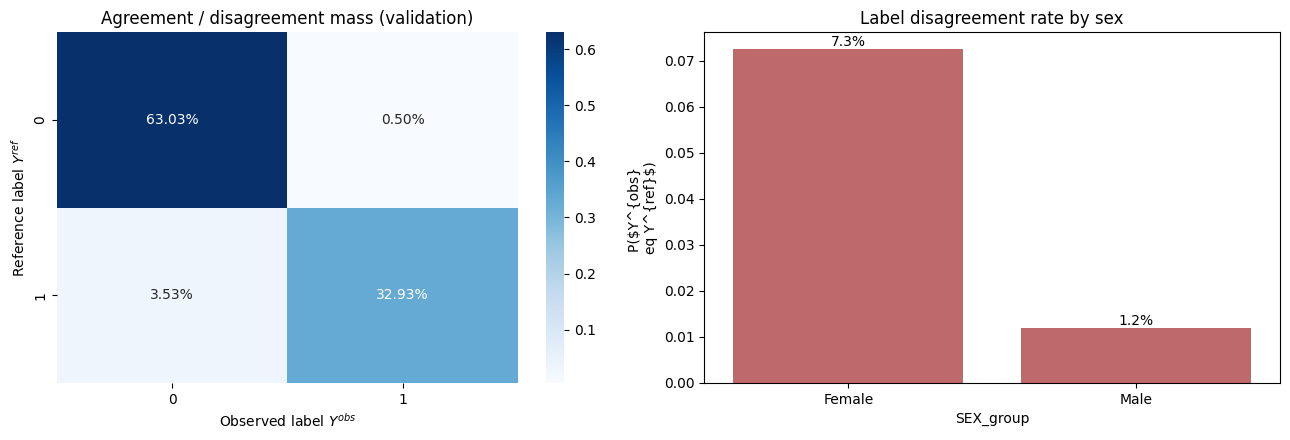

In [4]:
# --- Quantify and visualise label disagreement --------------------------------
val["is_disagreement"] = val["income_observed"] != val["income_reference"]
test["is_disagreement"] = test["income_observed"] != test["income_reference"]

print(f"Overall disagreement  validation: {val['is_disagreement'].mean():.4%}")
print(f"Overall disagreement  test:        {test['is_disagreement'].mean():.4%}")

ct = pd.crosstab(val["income_reference"], val["income_observed"],
                 rownames=["Y_ref"], colnames=["Y_obs"], margins=True)
print("\nValidation contingency table:")
display(ct)

fn = ((val["income_reference"] == 1) & (val["income_observed"] == 0)).mean()
fp = ((val["income_reference"] == 0) & (val["income_observed"] == 1)).mean()
print(f"P(Y_obs=0 | Y_ref=1)  high earners recorded as low: {fn:.4%}")
print(f"P(Y_obs=1 | Y_ref=0)  spurious positives:           {fp:.4%}")


def disagreement_table(frame, col):
    return (frame.groupby(col)["is_disagreement"]
            .agg(count="size", disagreement="mean")
            .sort_values("disagreement", ascending=False))


print("\nDisagreement by sex:")
display(disagreement_table(val, SEX_COL).round(4))
print("Disagreement by race:")
display(disagreement_table(val, RACE_COL).round(4))
print("Disagreement by survey batch:")
display(disagreement_table(val, "SURVEY_BATCH").round(4))

val["SEX_RACE"] = val[SEX_COL].astype(str) + " | " + val[RACE_COL].astype(str)
intersection = val.groupby("SEX_RACE")["is_disagreement"].agg(count="size", disagreement="mean")
print("Intersectional disagreement (n >= 50):")
display(intersection[intersection["count"] >= 50].sort_values("disagreement", ascending=False).round(4))

# Which feature regions contain the disagreements?
val["AGEP_bin"] = pd.cut(val["AGEP"], bins=[0, 25, 35, 45, 55, 65, 100])
val["WKHP_bin"] = pd.cut(val["WKHP"], bins=[0, 20, 35, 45, 60, 100])
print("Disagreement by age band:")
display(disagreement_table(val, "AGEP_bin").round(4))
print("Disagreement by weekly-hours band:")
display(disagreement_table(val, "WKHP_bin").round(4))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.heatmap(ct.iloc[:-1, :-1] / len(val), annot=True, fmt=".2%", cmap="Blues", ax=axes[0])
axes[0].set_title("Agreement / disagreement mass (validation)")
axes[0].set_ylabel("Reference label $Y^{ref}$")
axes[0].set_xlabel("Observed label $Y^{obs}$")

mismatch = val.groupby(SEX_COL)["is_disagreement"].mean().reset_index()
sns.barplot(data=mismatch, x=SEX_COL, y="is_disagreement", ax=axes[1], color="indianred")
axes[1].set_title("Label disagreement rate by sex")
axes[1].set_ylabel("P($Y^{obs} \neq Y^{ref}$)")
for i, row in mismatch.reset_index().iterrows():
    axes[1].text(i, row["is_disagreement"], f"{row['is_disagreement']:.1%}",
                 ha="center", va="bottom")
plt.tight_layout()
plt.show()

Re-evaluate the original model twice

For the same scores and decisions, produce two complete audits:

1. against `income_observed`;
2. against `income_reference`.

Any difference is caused by the evaluation target, not by a changed model. Discuss which conclusions reverse or materially change.

In [5]:
# --- Fit the original model on observed labels; audit the SAME scores twice ----
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), NUMERIC),
    ("cat", OneHotEncoder(handle_unknown="ignore"), CATEGORICAL),
])


def make_pipeline(**kwargs):
    return Pipeline([
        ("preprocess", preprocessor),
        ("model", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE, **kwargs)),
    ])


base_model = make_pipeline()
base_model.fit(train[FEATURES], y_obs_train)

# Dense transformed design matrices, reused by the Fairlearn reductions below.
X_train_trans = base_model[:-1].transform(train[FEATURES]).toarray()
X_val_trans = base_model[:-1].transform(val[FEATURES]).toarray()
X_test_trans = base_model[:-1].transform(test[FEATURES]).toarray()

val_score = base_model.predict_proba(val[FEATURES])[:, 1]
test_score = base_model.predict_proba(test[FEATURES])[:, 1]
val_pred = (val_score >= 0.5).astype(int)
test_pred = (test_score >= 0.5).astype(int)

print(f"Base model AUROC on validation vs Y_obs: {roc_auc_score(y_obs_val, val_score):.4f}")
print(f"Base model AUROC on validation vs Y_ref: {roc_auc_score(y_ref_val, val_score):.4f}")


def group_metrics(y_true, y_pred, groups):
    rows = {}
    for g in np.unique(groups):
        m = groups == g
        yt, yp = y_true[m], y_pred[m]
        tn, fp_, fn_, tp = confusion_matrix(yt, yp, labels=[0, 1]).ravel()
        rows[g] = {
            "n": int(m.sum()),
            "selection_rate": yp.mean(),
            "TPR": tp / (tp + fn_) if (tp + fn_) else np.nan,
            "FPR": fp_ / (fp_ + tn) if (fp_ + tn) else np.nan,
            "PPV": tp / (tp + fp_) if (tp + fp_) else np.nan,
            "NPV": tn / (tn + fn_) if (tn + fn_) else np.nan,
        }
    return pd.DataFrame(rows).T


def gap_summary(y_true, y_pred, groups):
    gm = group_metrics(y_true, y_pred, groups)
    return pd.Series({
        "selection_gap": gm["selection_rate"].max() - gm["selection_rate"].min(),
        "TPR_gap": gm["TPR"].max() - gm["TPR"].min(),
        "FPR_gap": gm["FPR"].max() - gm["FPR"].min(),
        "PPV_gap": gm["PPV"].max() - gm["PPV"].min(),
        "NPV_gap": gm["NPV"].max() - gm["NPV"].min(),
    })


print("\nBase model by sex, audited against Y_obs:")
display(group_metrics(y_obs_val, val_pred, A_val).round(3))
print("Base model by sex, audited against Y_ref:")
display(group_metrics(y_ref_val, val_pred, A_val).round(3))

audit = pd.DataFrame({
    "Y_obs": gap_summary(y_obs_val, val_pred, A_val),
    "Y_ref": gap_summary(y_ref_val, val_pred, A_val),
}).round(4)
print("Same model, two evaluation targets - gaps:")
display(audit)

Base model AUROC on validation vs Y_obs: 0.8592
Base model AUROC on validation vs Y_ref: 0.8743

Base model by sex, audited against Y_obs:


,n,selection_rate,TPR,FPR,PPV,NPV
Female,2812.0,0.147,0.396,0.076,0.597,0.843
Male,3188.0,0.422,0.745,0.175,0.765,0.809


Base model by sex, audited against Y_ref:


,n,selection_rate,TPR,FPR,PPV,NPV
Female,2812.0,0.147,0.414,0.042,0.795,0.806
Male,3188.0,0.422,0.749,0.168,0.776,0.810


Same model, two evaluation targets - gaps:


,Y_obs,Y_ref
selection_gap,0.2750,0.2750
TPR_gap,0.3495,0.3346
FPR_gap,0.0986,0.1262
PPV_gap,0.1686,0.0191
NPV_gap,0.0339,0.0039


HintL Design mitigation candidates

Compare at least four methods you could think of. You may add models. Every intervention requires a  rationale and a documented cost/tradeoff.

In [6]:
# --- Mitigation candidates: pre-, in- and post-processing ----------------------
# (1) Baseline: trained on the corrupted observed labels, no intervention.
# (2) Post-processing: ThresholdOptimizer picks group-specific thresholds to
#     equalise TPR/FPR. Fitted on the reference validation labels - a defended
#     choice, since reference validation is used only to choose thresholds and
#     never to fit model weights.
# (3) In-processing: ExponentiatedGradient under an equalized-odds constraint,
#     trained on the observed labels (the constraint is only as good as the labels).
# (4) Pre-processing: inverse-noise-rate reweighting of the training examples,
#     using sex-specific mislabel rates estimated on reference validation.
# (5) In-processing: standard class-weight balancing, which reweights the two
#     observed classes inversely to their training frequency. It uses no
#     reference labels and assumes nothing about the noise mechanism.


def estimate_noise_rates(y_ref, y_obs, groups):
    '''Per group: sensitivity P(Y_obs=1|Y_ref=1) and fpr P(Y_obs=1|Y_ref=0).'''
    rates = {}
    for g in np.unique(groups):
        m = groups == g
        yr, yo = y_ref[m], y_obs[m]
        sens = ((yo == 1) & (yr == 1)).sum() / max((yr == 1).sum(), 1)
        fpr = ((yo == 1) & (yr == 0)).sum() / max((yr == 0).sum(), 1)
        rates[g] = (sens, fpr)
    return rates


noise_rates = estimate_noise_rates(y_ref_val, y_obs_val, A_val)
print("Estimated label noise per sex:")
for g, (a, b) in noise_rates.items():
    print(f"  {g:6s} sensitivity=P(Y_obs=1|Y_ref=1)={a:.3f}   "
          f"fpr=P(Y_obs=1|Y_ref=0)={b:.3f}")


# (4) inverse-noise-rate sample weights
sample_weight = np.ones(len(train))
for g in np.unique(A_train):
    a, b = noise_rates[g]
    m = A_train == g
    sample_weight[m & (y_obs_train == 1)] = 1.0 / max(a, 1e-3)
    sample_weight[m & (y_obs_train == 0)] = 1.0 / max(1 - b, 1e-3)

reweighted_model = make_pipeline()
reweighted_model.fit(train[FEATURES], y_obs_train, model__sample_weight=sample_weight)

# (5) standard class-weight balancing (no reference labels involved)
balanced_model = make_pipeline(class_weight="balanced")
balanced_model.fit(train[FEATURES], y_obs_train)
val_score_balanced = balanced_model.predict_proba(val[FEATURES])[:, 1]
test_score_balanced = balanced_model.predict_proba(test[FEATURES])[:, 1]

# (3) in-processing
eg_model = ExponentiatedGradient(
    estimator=LogisticRegression(max_iter=500, random_state=RANDOM_STATE),
    constraints=EqualizedOdds(),
    max_iter=15,
)
eg_model.fit(X_train_trans, y_obs_train, sensitive_features=A_train)

# (2) post-processing on reference validation labels
threshold_model = ThresholdOptimizer(
    estimator=base_model,
    constraints="equalized_odds",
    predict_method="predict_proba",
    prefit=True,
)
threshold_model.fit(val[FEATURES], y_ref_val, sensitive_features=A_val)

candidates = {
    "1. Baseline LR": val_pred,
    "2. ThresholdOptimizer (Y_ref)": threshold_model.predict(val[FEATURES], sensitive_features=A_val).astype(int),
    "3. ExponentiatedGradient (Y_obs)": eg_model.predict(X_val_trans).astype(int),
    "4. Reweighted LR": (reweighted_model.predict_proba(val[FEATURES])[:, 1] >= 0.5).astype(int),
    "5. Class-weighted LR": (val_score_balanced >= 0.5).astype(int),
}

rows = []
for name, pred in candidates.items():
    for target, yt in [("Y_obs", y_obs_val), ("Y_ref", y_ref_val)]:
        gs = gap_summary(yt, pred, A_val)
        rows.append({
            "Candidate": name, "Target": target,
            "BalancedAcc": balanced_accuracy_score(yt, pred),
            "Sel_gap": gs["selection_gap"], "TPR_gap": gs["TPR_gap"],
            "FPR_gap": gs["FPR_gap"], "PPV_gap": gs["PPV_gap"],
        })
comparison = pd.DataFrame(rows)
print("\nValidation comparison (identical protocol, two evaluation targets):")
display(comparison.pivot(index="Candidate", columns="Target",
                         values=["BalancedAcc", "Sel_gap", "TPR_gap", "FPR_gap", "PPV_gap"]).round(4))

print(f"Reweighted examples (candidate 4): {int((sample_weight != 1).sum())} / {len(sample_weight)} "
      f"(weight range {sample_weight.min():.2f}-{sample_weight.max():.2f})")

Estimated label noise per sex:
  Female sensitivity=P(Y_obs=1|Y_ref=1)=0.764   fpr=P(Y_obs=1|Y_ref=0)=0.008
  Male   sensitivity=P(Y_obs=1|Y_ref=1)=0.982   fpr=P(Y_obs=1|Y_ref=0)=0.007

Validation comparison (identical protocol, two evaluation targets):


BalancedAcc         Sel_gap         TPR_gap  \
Target                                 Y_obs   Y_ref   Y_obs   Y_ref   Y_obs   
Candidate                                                                      
1. Baseline LR                        0.7578  0.7630  0.2750  0.2750  0.3495   
2. ThresholdOptimizer (Y_ref)         0.7626  0.7925  0.0901  0.0901  0.0563   
3. ExponentiatedGradient (Y_obs)      0.7305  0.7507  0.0962  0.0962  0.0701   
4. Reweighted LR                      0.7609  0.7730  0.2352  0.2352  0.2753   
5. Class-weighted LR                  0.7726  0.7911  0.2716  0.2716  0.2459   

                                         FPR_gap         PPV_gap          
Target                             Y_ref   Y_obs   Y_ref   Y_obs   Y_ref  
Candidate                                                                 
1. Baseline LR                    0.3346  0.0986  0.1262  0.1686  0.0191  
2. ThresholdOptimizer (Y_ref)     0.0008  0.0562  0.0003  0.3051  0.1398  
3. ExponentiatedGradient (Y_obs)  0.0250  0.0326  0.0158  0.2914  0.1083  
4. Reweighted LR                  0.2489  0.0689  0.1044  0.2120  0.0283  
5. Class-weighted LR              0.1987  0.1290  0.1795  0.1904  0.0157

Reweighted examples (candidate 4): 18000 / 18000 (weight range 1.01-1.31)


Hint: `ThresholdOptimizer` changes decisions, not probability calibration. `ExponentiatedGradient` trains a randomized classifier under a constraint. Equalized odds is evaluated relative to the label supplied during fitting.

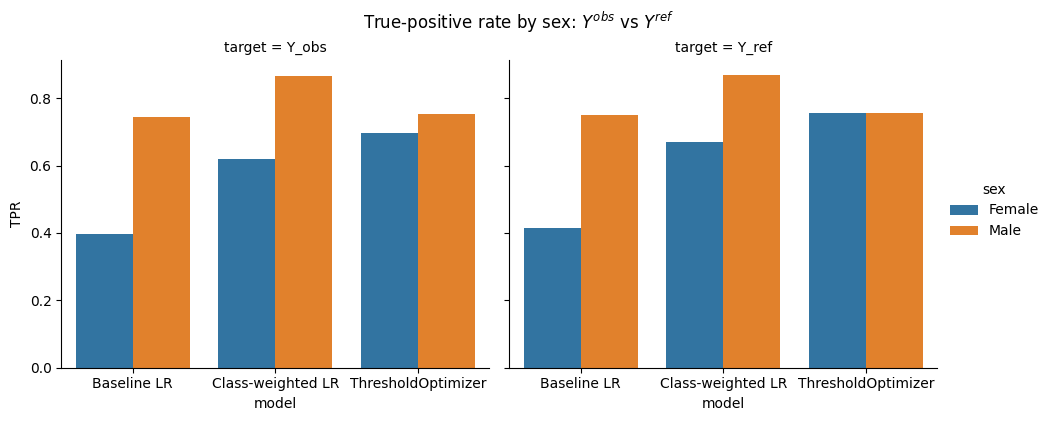

Selection vs reference base rate by sex (baseline decisions):
  Female: selected 0.147 | Y_ref positive rate 0.282 | Y_obs positive rate 0.222
  Male  : selected 0.422 | Y_ref positive rate 0.437 | Y_obs positive rate 0.434


In [7]:
# --- Which conclusions change when the evaluation target changes? --------------
# The baseline looks far worse on TPR parity under Y_ref than under Y_obs, because
# the observed labels delete high-income women. Class-weight balancing lifts the
# decision rate for the under-represented positive class, narrowing the TPR gap at
# some cost to precision.


def tpr_by_sex(y_true, pred):
    return pd.Series({g: pred[(A_val == g) & (y_true == 1)].mean()
                      for g in np.unique(A_val)})


plot_rows = []
for model_name, pred in [
    ("Baseline LR", val_pred),
    ("Class-weighted LR", (val_score_balanced >= 0.5).astype(int)),
    ("ThresholdOptimizer", candidates["2. ThresholdOptimizer (Y_ref)"]),
]:
    for target, yt in [("Y_obs", y_obs_val), ("Y_ref", y_ref_val)]:
        for g, v in tpr_by_sex(yt, pred).items():
            plot_rows.append({"model": model_name, "target": target, "sex": g, "TPR": v})
plot_df = pd.DataFrame(plot_rows)
g = sns.catplot(data=plot_df, x="model", y="TPR", hue="sex", col="target", kind="bar",
                height=4, aspect=1.2)
g.fig.suptitle("True-positive rate by sex: $Y^{obs}$ vs $Y^{ref}$", y=1.04)
plt.show()

print("Selection vs reference base rate by sex (baseline decisions):")
for g_ in np.unique(A_val):
    m = A_val == g_
    print(f"  {g_:6s}: selected {val_pred[m].mean():.3f} | "
          f"Y_ref positive rate {y_ref_val[m].mean():.3f} | "
          f"Y_obs positive rate {y_obs_val[m].mean():.3f}")

Compare at least these score pipelines:

1. uncalibrated model;
2. calibration fitted to observed validation labels;
3. calibration fitted to reference validation labels.

Evaluate each against both observed and reference test labels. Keep calibration separate from decision postprocessing. Explain why a score can be calibrated against one label and miscalibrated against another.

,ECE vs Y_obs,LogLoss vs Y_obs,ECE vs Y_ref,LogLoss vs Y_ref
Pipeline,,,,
Uncalibrated,0.0151,0.4337,0.0312,0.4289
Calibrated on Y_obs,0.0129,0.4335,0.0351,0.4293
Calibrated on Y_ref,0.0303,0.4377,0.0143,0.4252


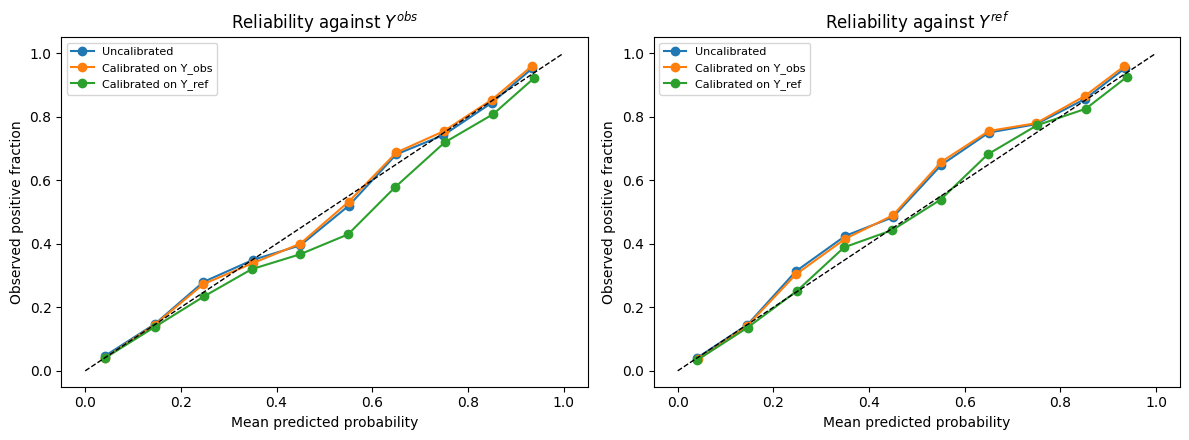

In [8]:
# --- Score calibration: three pipelines, evaluated against both labels ---------
# Calibration is a property of the SCORES (not the decisions) and is always
# relative to a target label. A score calibrated against Y_obs is miscalibrated
# against Y_ref whenever label noise is correlated with the score or the group.


def expected_calibration_error(y_true, y_prob, n_bins=10):
    edges = np.linspace(0, 1, n_bins + 1)
    bins = np.digitize(y_prob, edges[1:-1])
    ece = 0.0
    for b in range(n_bins):
        m = bins == b
        if m.sum() > 0:
            ece += m.sum() * abs(y_true[m].mean() - y_prob[m].mean())
    return ece / len(y_true)


calibrated_obs = CalibratedClassifierCV(FrozenEstimator(base_model), method="sigmoid")
calibrated_obs.fit(val[FEATURES], y_obs_val)
calibrated_ref = CalibratedClassifierCV(FrozenEstimator(base_model), method="sigmoid")
calibrated_ref.fit(val[FEATURES], y_ref_val)

score_pipelines = {
    "Uncalibrated": val_score,
    "Calibrated on Y_obs": calibrated_obs.predict_proba(val[FEATURES])[:, 1],
    "Calibrated on Y_ref": calibrated_ref.predict_proba(val[FEATURES])[:, 1],
}

calib_rows = []
for name, sc in score_pipelines.items():
    calib_rows.append({
        "Pipeline": name,
        "ECE vs Y_obs": expected_calibration_error(y_obs_val, sc),
        "LogLoss vs Y_obs": log_loss(y_obs_val, sc),
        "ECE vs Y_ref": expected_calibration_error(y_ref_val, sc),
        "LogLoss vs Y_ref": log_loss(y_ref_val, sc),
    })
display(pd.DataFrame(calib_rows).set_index("Pipeline").round(4))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for name, sc in score_pipelines.items():
    for ax, (target, yt) in zip(axes, [("Y_obs", y_obs_val), ("Y_ref", y_ref_val)]):
        frac, mean_pred = calibration_curve(yt, sc, n_bins=10, strategy="uniform")
        ax.plot(mean_pred, frac, marker="o", label=name)
for ax, target in zip(axes, ["$Y^{obs}$", "$Y^{ref}$"]):
    ax.plot([0, 1], [0, 1], "k--", linewidth=1)
    ax.set_title(f"Reliability against {target}")
    ax.set_xlabel("Mean predicted probability")
    ax.set_ylabel("Observed positive fraction")
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## 5. Final locked test evaluation

Select the final candidates before examining reference test results. Then produce evaluate a comparison with:

- performance against $Y^{obs}$ and $Y^{ref}$;
- sex-specific and intersectional counts;
- selection-rate gap;
- TPR and FPR gaps;
- PPV and NPV gaps;
- AUROC, log loss, and calibration error;
- bootstrap intervals for key gaps;
- number of training examples removed/reweighted;
- features required at deployment.
- etc

In [9]:
# --- Locked selection (made from validation-reference evidence) ----------------
# Finalists: baseline (reference point), ThresholdOptimizer (best separation
# parity), class-weighted LR (standard in-processing mitigation that requires no
# reference labels). The reference TEST labels are used exactly once, below.
finalists = {
    "Baseline LR": (test_pred, test_score),
    "ThresholdOptimizer (Y_ref)": (
        threshold_model.predict(test[FEATURES], sensitive_features=A_test).astype(int), None),
    "Class-weighted LR": ((test_score_balanced >= 0.5).astype(int), test_score_balanced),
}


def evaluate_final(pred, score, y_ref, y_obs):
    return {
        "Accuracy (Y_ref)": accuracy_score(y_ref, pred),
        "Balanced acc (Y_ref)": balanced_accuracy_score(y_ref, pred),
        "AUROC (Y_ref)": roc_auc_score(y_ref, score) if score is not None else np.nan,
        "LogLoss (Y_ref)": log_loss(y_ref, score) if score is not None else np.nan,
        "ECE (Y_ref)": expected_calibration_error(y_ref, score) if score is not None else np.nan,
        "Accuracy (Y_obs)": accuracy_score(y_obs, pred),
        "Balanced acc (Y_obs)": balanced_accuracy_score(y_obs, pred),
        "ECE (Y_obs)": expected_calibration_error(y_obs, score) if score is not None else np.nan,
    }


overall = pd.DataFrame({name: evaluate_final(pred, score, y_ref_test, y_obs_test)
                        for name, (pred, score) in finalists.items()}).T
print("Final test - overall performance (reference test used once):")
display(overall.round(4))

gap_rows = []
for name, (pred, score) in finalists.items():
    gap_rows.append({"Candidate": name, **gap_summary(y_ref_test, pred, A_test).to_dict()})
print("Final test - fairness gaps vs Y_ref:")
display(pd.DataFrame(gap_rows).set_index("Candidate").round(4))

print("Final test - per-sex metrics vs Y_ref (baseline):")
display(group_metrics(y_ref_test, finalists["Baseline LR"][0], A_test).round(3))
print("Final test - per-sex metrics vs Y_ref (class-weighted):")
display(group_metrics(y_ref_test, finalists["Class-weighted LR"][0], A_test).round(3))

test["SEX_RACE"] = test[SEX_COL].astype(str) + " | " + test[RACE_COL].astype(str)
inter = group_metrics(y_ref_test, finalists["Class-weighted LR"][0], test["SEX_RACE"].values)
print("Final test - intersectional metrics (n >= 30), class-weighted:")
display(inter[inter["n"] >= 30].round(3))

# Bootstrap intervals for the key gaps (reference test)
def bootstrap_gap(pred, y_true, groups, metric="selection", n_boot=500, seed=RANDOM_STATE):
    rng = np.random.default_rng(seed)
    n = len(y_true)
    stats = []
    for _ in range(n_boot):
        idx = rng.integers(0, n, n)
        if metric == "selection":
            gm = pd.Series(pred[idx]).groupby(pd.Series(groups[idx])).mean()
            stats.append(gm.max() - gm.min())
        else:
            gm = group_metrics(y_true[idx], pred[idx], groups[idx])
            stats.append(np.nanmax(gm[metric]) - np.nanmin(gm[metric]))
    return np.percentile(stats, [2.5, 97.5])


boot_rows = []
for name, (pred, score) in finalists.items():
    for metric in ["selection", "TPR", "FPR"]:
        lo, hi = bootstrap_gap(pred, y_ref_test, A_test, metric=metric)
        boot_rows.append({"Candidate": name, "metric": metric, "lo": lo, "hi": hi})
print("Bootstrap 95% intervals for test gaps vs Y_ref:")
display(pd.DataFrame(boot_rows).pivot(index="Candidate", columns="metric",
                                      values=["lo", "hi"]).round(3))

print("\nDeployment / cost accounting:")
print("  Features required at inference:", FEATURES)
print("  Sensitive attribute required at inference by ThresholdOptimizer:", SEX_COL)
print("  Reference labels required: validation only (ThresholdOptimizer thresholds)")
print(f"  Training examples reweighted (candidate 4): {int((sample_weight != 1).sum())} / {len(sample_weight)}")
print("  Training examples removed: 0 (reweighting only)")

Final test - overall performance (reference test used once):


,Accuracy (Y_ref),Balanced acc (Y_ref),AUROC (Y_ref),LogLoss (Y_ref),ECE (Y_ref),Accuracy (Y_obs),Balanced acc (Y_obs),ECE (Y_obs)
Baseline LR,0.7992,0.7642,0.8780,0.4235,0.0336,0.7953,0.7569,0.0086
ThresholdOptimizer (Y_ref),0.8002,0.7903,NaN,NaN,NaN,0.7707,0.7616,NaN
Class-weighted LR,0.7942,0.7968,0.8783,0.4362,0.0690,0.7697,0.7773,0.1018


Final test - fairness gaps vs Y_ref:


,selection_gap,TPR_gap,FPR_gap,PPV_gap,NPV_gap
Candidate,,,,,
Baseline LR,0.2700,0.3047,0.1336,0.0333,0.0068
ThresholdOptimizer (Y_ref),0.0945,0.0050,0.0098,0.1276,0.0869
Class-weighted LR,0.2830,0.2086,0.1893,0.0050,0.0104


Final test - per-sex metrics vs Y_ref (baseline):


...

Final test - intersectional metrics (n >= 30), class-weighted:


,n,selection_rate,TPR,FPR,PPV,NPV
Female | Asian,147.0,0.347,0.791,0.163,0.667,0.906
Female | Black,299.0,0.227,0.605,0.075,0.765,0.853
Female | Other race,143.0,0.112,0.346,0.060,0.562,0.866
Female | Two or more races,71.0,0.239,0.643,0.140,0.529,0.907
Female | White,2129.0,0.296,0.693,0.133,0.683,0.872
Male | Asian,168.0,0.696,0.958,0.356,0.778,0.922
Male | Black,272.0,0.342,0.747,0.176,0.634,0.888
Male | Other race,162.0,0.302,0.676,0.192,0.510,0.894
Male | Two or more races,53.0,0.491,1.000,0.308,0.538,1.000
Male | White,2518.0,0.596,0.891,0.342,0.692,0.875


Bootstrap 95% intervals for test gaps vs Y_ref:


lo                      hi                 
metric                        FPR    TPR selection    FPR    TPR selection
Candidate                                                                 
Baseline LR                 0.115  0.266     0.249  0.153  0.348     0.291
Class-weighted LR           0.164  0.171     0.258  0.213  0.245     0.304
ThresholdOptimizer (Y_ref)  0.000  0.001     0.073  0.031  0.045     0.119


Deployment / cost accounting:
  Features required at inference: ['AGEP', 'COW', 'SCHL', 'MAR', 'OCCP', 'POBP', 'RELP', 'WKHP', 'SEX', 'RAC1P']
  Sensitive attribute required at inference by ThresholdOptimizer: SEX_group
  Reference labels required: validation only (ThresholdOptimizer thresholds)
  Training examples reweighted (candidate 4): 18000 / 18000
  Training examples removed: 0 (reweighting only)


## Questions to think about!

1. Which Week 2 conclusions were robust to the reference label audit?
2. Which apparent performance or fairness results were artifacts of $Y^{obs}$?
3. How did the suspected issue X affect in-distribution validation and shifted test performance?
4. How methods/framework helped you find issues in the data? How do you know?
5. Which mitigation improved reference performance, and what did it cost?
6. Did a parity intervention improve the chosen harm-related metric against the correct label?
7. How did observed-label and reference-label calibration differ?
8. Why can equalized odds and calibration conflict when group base rates differ?
9. What evidence would be required before changing real labels or deploying group-specific thresholds?
10. What remains unvalidated?

# 📌 Final Submission for Project 1: A0 Poster

You are instructed to submit an A0 poster summarizing  findings across the three weeks.

## 📋 Recommended Poster Structure

### Introduction & Setup (very breifly)

* The prediction task, dataset, and outcome. 
* The critical distinction between $Y^{obs}$ (the potential corrupted label) and $Y^{ref}$ (the clean ground-truth label).

### Week 1: Baseline Fairness Audit

* Overall and group-specific predictive performance.
* Fairness metrics considered and the real-world trade-offs observed.

### Week 2: Blind Audit (Observed Labels)

* You must explain initial hypotheses (e.g., Data collection flaws? Group-dependent errors? Spurious correlations?).
* What audit methods they used, their strongest evidence, and whether they trust derived scores as ground truth.

### Week 3: Reference Label Evaluation and Mitigation

* Reveal the hidden data problem using $Y^{ref}$ and quantify the disagreement between the observed and reference labels.
* Discuss whether your Week 2 hypotheses were correct.
* Mitigation: Compare a justified set of interventions. Report the effect on performance, fairness, calibration, and any adverse effects.
* Final Selection: Present the final model selection and its evaluation on the reference test set.
* Discussion and Conclusion

### Important

* Use visual evidence (tables/figures) throughout the poster. Focus on interpretation over code.

* Report relevant negative or inconclusive findings. What remains unvalidated?